# Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [4]:
# Import libraries used in this notebook
import os
import cv2
import numpy as np
import pandas as pd
import random
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
import torchvision.transforms as transforms
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# Set File path for Image Data
#data_filepath = '/content/drive/MyDrive/data/chest_xray'
data_filepath = '../data/chest_xray'

In [5]:
import torch

# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda

NVIDIA GeForce RTX 4070 Laptop GPU
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


# Dataset Loading

In [6]:
# Create a DataFrame of image paths and their corresponding numeric label (0 = Normal, 1 = Pneumonia)
image_dirs = ['train']  # ✅ Only using training dataset for now
data = []

# ✅ Define label mapping: 'NORMAL' → 0, 'PNEUMONIA' → 1
label_mapping = {"NORMAL": 0, "PNEUMONIA": 1}

# Loop through Image Directories to find images
for dir in image_dirs:
    dir_path = os.path.join(data_filepath, dir)
    
    for label_name in ["NORMAL", "PNEUMONIA"]:
        label_dir = os.path.join(dir_path, label_name)
        
        for file_name in os.listdir(label_dir):
            file_path = os.path.join(label_dir, file_name)

            if file_name.endswith(('.png', '.jpg', '.jpeg')):  # ✅ Ensure valid image file
                data.append([dir, file_path, label_mapping[label_name]])  # ✅ Store label as an integer

# Create DataFrame
df = pd.DataFrame(data, columns=["directory", "image_path", "label"])
df


,directory,image_path,label
0,train,../data/chest_xray\train\NORMAL\IM-0115-0001.jpeg,0
1,train,../data/chest_xray\train\NORMAL\IM-0117-0001.jpeg,0
2,train,../data/chest_xray\train\NORMAL\IM-0119-0001.jpeg,0
3,train,../data/chest_xray\train\NORMAL\IM-0122-0001.jpeg,0
4,train,../data/chest_xray\train\NORMAL\IM-0125-0001.jpeg,0
...,...,...,...
5211,train,../data/chest_xray\train\PNEUMONIA\person99_vi...,1
5212,train,../data/chest_xray\train\PNEUMONIA\person9_bac...,1
5213,train,../data/chest_xray\train\PNEUMONIA\person9_bac...,1
5214,train,../data/chest_xray\train\PNEUMONIA\person9_bac...,1


In [7]:
class XrayImageDataset(Dataset):
    def __init__(self, df_imagepaths, transform=None):
        self.df_imagepaths = df_imagepaths  # ✅ Store DataFrame
        self.transform = transform  # ✅ Store transforms

    def __getitem__(self, idx):
        # ✅ Correct way to get image path
        img_path = self.df_imagepaths.iloc[idx]["image_path"]
        image = Image.open(img_path).convert("L")  # ✅ Load as grayscale

        # ✅ Correct way to get label (Already Integer!)
        label = self.df_imagepaths.iloc[idx]["label"]

        # ✅ Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        return image, label  # ✅ Returns both image and numeric label

    def __len__(self):
        return len(self.df_imagepaths)  # ✅ Correctly returns dataset size


5216
Label: 0 (0: NORMAL, 1: PNEUMONIA)


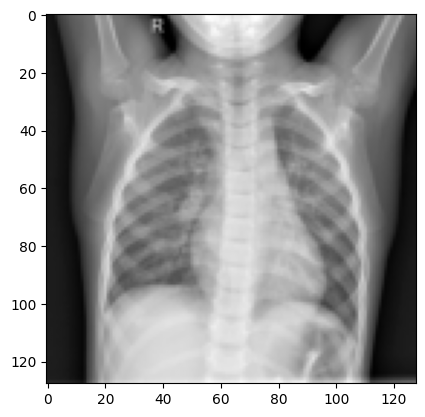

In [8]:
xray_transform = transforms.Compose([
    transforms.Resize((128,128)),  # ✅ Resize for consistency
    transforms.ToTensor(),  # ✅ Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # ✅ Normalize for DCGAN
])

xray_dataset = XrayImageDataset(df, transform=xray_transform)
print(len(xray_dataset))  # Check total dataset size
image, label = xray_dataset[0]  # Get the first image-label pair
plt.imshow(image.squeeze(), cmap="gray")  # Display the image
print(f"Label: {label} (0: NORMAL, 1: PNEUMONIA)")  # ✅ Explicitly state what the label means


# Model Definition

In [9]:
# ✅ Hyperparameters for ACGAN (128x128 Images)

# Random seed for reproducibility
manualSeed = 999
torch.manual_seed(manualSeed)

# Model architecture
image_size = 128  # ✅ Set for 128x128 images
nc = 1  # ✅ Number of channels (Grayscale X-ray)
nz = 100  # ✅ Latent space dimension
num_classes = 2  # ✅ Pneumonia vs Normal classification

# ✅ Increased feature maps to handle larger images
ngf = 256  # ✅ Generator feature maps (was 128, now 256)
ndf = 128  # ✅ Discriminator feature maps (was 64, now 128)
ngpu = 1   # ✅ Number of GPUs

# Training details
batch_size = 32  # ✅ Reduced batch size (higher memory usage at 128x128)
num_epochs = 5000  # ✅ Maximum epochs

# Learning rates
lr_g = 0.0002  # ✅ Generator learning rate (kept same)
lr_d = 0.00001  # ✅ ✅ Lowered Discriminator learning rate (4x slower than G)

# Optimizer settings
optimizer_type = "Adam"  # ✅ Using Adam for stability
betas = (0.5, 0.999)  # ✅ Recommended betas for GAN training

# Regularization
netd_dropout = 0.2  # ✅ ✅ Reduced dropout in Discriminator (weaken D slightly)

# Learning Rate Scheduler
scheduler_step_size = 10000  # ✅ Step size before reducing LR
scheduler_gamma = 0.5  # ✅ Decay factor

# Label smoothing settings (for stability)
real_label_smooth = 0.98  # ✅ Adjusted for real images
fake_label_smooth = 0.0  # ✅ Adjusted for fake images

# Generator update frequency (controls how often G is updated per D step)
gen_update_steps = 2  # ✅ Changed from 5 to 2 (adjustable)

# Discriminator Gaussian noise (weakens D)
discriminator_noise_std = 0.15  # ✅ Adds noise to weaken D slightly

# ✅ ACGAN-specific parameters
lambda_class = 1.0  # ✅ Weight for class prediction loss (tune if needed)
criterion_class = nn.CrossEntropyLoss()  # ✅ ACGAN: Class prediction loss

# Early stopping parameters
min_epochs = 500  # ✅ Minimum epochs before stopping
patience = 50  # ✅ Consecutive epochs without improvement before stopping
g_d_loss_delta = 0.002  # ✅ Improvement threshold
min_loss = float('inf')  # ✅ Track best loss
epochs_no_improve = 0  # ✅ Counter for early stopping
early_stop = False  # ✅ Early stopping flag


In [10]:
# ✅ Custom weights initialization for netG and netD (ACGAN Style)
def weights_init(m):
    classname = m.__class__.__name__
    
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02) 
    
    elif isinstance(m, nn.BatchNorm2d):  
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    
    # ✅ Initialize fully connected layers in Discriminator (real/fake & class)
    elif isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)  # ✅ Xavier init for stability
        nn.init.constant_(m.bias, 0)  # ✅ Zero bias


In [11]:
class Generator(nn.Module):
    def __init__(self, ngpu, num_classes):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.num_classes = num_classes

        # 🔹 One-hot encoded label embedding (num_classes instead of nz)
        self.label_emb = nn.Embedding(num_classes, num_classes)

        # 🔹 Initial Transpose Layer now expects (nz + num_classes) channels
        self.init_layer = nn.Sequential(
            nn.ConvTranspose2d(nz + num_classes, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
        )

        # 🔹 Upsampling Blocks (Now includes 4 layers for 128x128)
        self.block1 = self._make_block(ngf * 8, ngf * 4)  # 4x4 → 8x8
        self.block2 = self._make_block(ngf * 4, ngf * 2)  # 8x8 → 16x16
        self.block3 = self._make_block(ngf * 2, ngf)      # 16x16 → 32x32
        self.block4 = self._make_block(ngf, ngf // 2)     # 32x32 → 64x64

        # 🔹 Final layer for 128x128 output
        self.final = nn.Sequential(
            nn.ConvTranspose2d(ngf // 2, nc, 4, 2, 1, bias=False),  # ✅ Outputs 128x128
            nn.Tanh()
        )

    def _make_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
        )

    def forward(self, noise, labels):
        label_embedding = F.one_hot(labels, num_classes).float().to(device)  # ✅ Convert labels to one-hot
        label_embedding = label_embedding.unsqueeze(2).unsqueeze(3)  # ✅ Add dimensions for concatenation
        gen_input = torch.cat((noise, label_embedding), dim=1)  # ✅ Concatenate along channels
        gen_input = gen_input.view(gen_input.shape[0], nz + num_classes, 1, 1)  # ✅ Adjust input channels
        return self.final(self.block4(self.block3(self.block2(self.block1(self.init_layer(gen_input))))))


In [12]:
class Discriminator(nn.Module):
    def __init__(self, ngpu, num_classes):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu

        self.conv_layers = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),  # (ndf) x 64 x 64
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(netd_dropout),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),  # (ndf*2) x 32 x 32
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(netd_dropout),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),  # (ndf*4) x 16 x 16
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(netd_dropout),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),  # (ndf*8) x 8 x 8
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(netd_dropout),

            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),  # (ndf*16) x 4 x 4
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(netd_dropout),
        )

        # 🔹 Real/Fake Output Head
        self.validity_head = nn.Sequential(
            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

        # 🔹 Class Prediction Output Head
        self.class_head = nn.Sequential(
            nn.Conv2d(ndf * 16, num_classes, 4, 1, 0, bias=False),
            nn.Flatten(),
            nn.Softmax(dim=1)  # ✅ Ensures probability distribution over classes
        )

    def forward(self, input):
        x = self.conv_layers(input)
        validity = self.validity_head(x).view(-1)  
        class_output = self.class_head(x)  
        return validity, class_output


In [ ]:
# ✅ Create the generator (ACGAN: Includes class conditioning)
netG = Generator(ngpu, num_classes).to(device)

# ✅ Explicitly reinitialize weights before training
netG.apply(weights_init)

# Handle multi-GPU if needed
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Print model structure AFTER moving to GPU
print("✅ Generator Model:")
print(netG)

# ✅ Create the discriminator (ACGAN: Predicts both real/fake and class labels)
netD = Discriminator(ngpu, num_classes).to(device)

# ✅ Explicitly reinitialize weights before training
netD.apply(weights_init)

# Handle multi-GPU if needed
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Print model structure AFTER moving to GPU
print("✅ Discriminator Model:")
print(netD)


✅ Generator Model:
Generator(
  (label_emb): Embedding(2, 2)
  (init_layer): Sequential(
    (0): ConvTranspose2d(102, 2048, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block1): Sequential(
    (0): ConvTranspose2d(2048, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block2): Sequential(
    (0): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block3): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [ ]:
# ✅ Initialize Loss Functions for ACGAN
criterion_GAN = nn.BCELoss()  # Binary cross-entropy for real/fake classification
criterion_class = nn.CrossEntropyLoss()  # ✅ ACGAN: Class prediction loss

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move models to GPU BEFORE defining optimizers
netG.to(device)
netD.to(device)
criterion_GAN.to(device)
criterion_class.to(device)  # ✅ Move class loss to GPU

# Create batch of latent vectors for visualization
fixed_noise = torch.randn(batch_size, nz, 1, 1, device=device)
fixed_labels = torch.randint(0, num_classes, (batch_size,), dtype=torch.long, device=device)  # ✅ Explicitly set dtype to long

# Establish real and fake labels with smoothing
real_label_base = 0.9
fake_label_base = 0.1

# ✅ Use Adam for both Generator & Discriminator (ACGAN)
optimizerD = optim.Adam(netD.parameters(), lr=lr_d, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr_g, betas=(0.5, 0.999))

# Initialize learning rate schedulers for gradual decay
schedulerD = torch.optim.lr_scheduler.StepLR(optimizerD, step_size=scheduler_step_size, gamma=scheduler_gamma)
schedulerG = torch.optim.lr_scheduler.StepLR(optimizerG, step_size=scheduler_step_size, gamma=scheduler_gamma)

# Custom collate function to avoid shape mismatches in batch processing
def custom_collate_fn(batch):
    images = torch.stack([b[0] for b in batch])  # ✅ Stack image tensors
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)  # ✅ Ensure labels are long tensor
    return images, labels

# Optimize DataLoader for GPU efficiency
dataloader = DataLoader(
    xray_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=custom_collate_fn  # ✅ Using defined function instead of lambda
)

# ✅ Check if models are on GPU
print(f"Generator on GPU? {next(netG.parameters()).is_cuda}")
print(f"Discriminator on GPU? {next(netD.parameters()).is_cuda}")


Using device: cuda
Generator on GPU? True
Discriminator on GPU? True


# Model Training Loop

In [ ]:
import time

def display_generated_images(fake_images, epoch):
    """
    Displays a grid of generated images every n epochs.
    """
    if (epoch + 1) % 50 == 0:
        fake_images = fake_images.cpu().detach()  # ✅ Ensure tensor is detached before moving to CPU
        grid = vutils.make_grid(fake_images, padding=2, normalize=True)
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Generated Images - Epoch {epoch+1}")
        plt.imshow(grid.permute(1, 2, 0))
        plt.show()

def print_processing_status(epoch, num_epochs, start_time):
    """
    Prints the training progress every n epochs with time taken.
    """
    if (epoch + 1) % 25 == 0:
        elapsed_time = time.time() - start_time
        print(f"🕒 Epoch {epoch+1}/{num_epochs} completed in {elapsed_time:.2f} sec.")


🚀 Starting Training Loop...
[0/5000][0/163] Loss_D: 4.0570 Loss_G: 0.6480 D(x): 0.3186 D(G(z)): 0.1950 / 0.9815
[6/5000][22/163] Loss_D: 3.3585 Loss_G: 0.3337 D(x): 0.5756 D(G(z)): 0.6936 / 0.9814
[12/5000][44/163] Loss_D: 3.4469 Loss_G: 0.3369 D(x): 0.3276 D(G(z)): 0.4893 / 0.9776
[18/5000][66/163] Loss_D: 2.8587 Loss_G: 0.3374 D(x): 0.5704 D(G(z)): 0.6458 / 0.9771
[24/5000][88/163] Loss_D: 2.6521 Loss_G: 0.3487 D(x): 0.4693 D(G(z)): 0.5320 / 0.9663
🕒 Epoch 25/5000 completed in 92.31 sec.
[30/5000][110/163] Loss_D: 2.5273 Loss_G: 0.3915 D(x): 0.3644 D(G(z)): 0.4065 / 0.9299
[36/5000][132/163] Loss_D: 2.8659 Loss_G: 0.4364 D(x): 0.3641 D(G(z)): 0.4919 / 0.8963
[42/5000][154/163] Loss_D: 1.9976 Loss_G: 0.5879 D(x): 0.5638 D(G(z)): 0.4776 / 0.7793
[49/5000][13/163] Loss_D: 2.1509 Loss_G: 0.6189 D(x): 0.5029 D(G(z)): 0.4550 / 0.7507


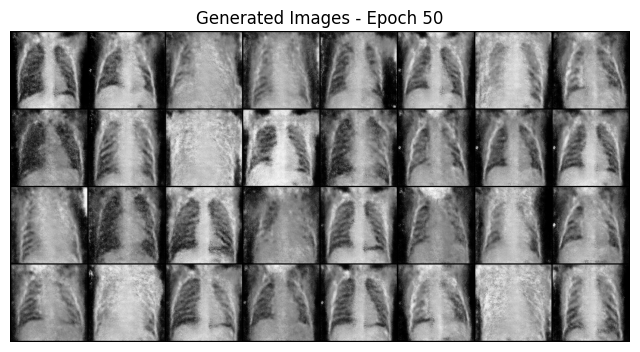

🕒 Epoch 50/5000 completed in 92.43 sec.
[55/5000][35/163] Loss_D: 2.3541 Loss_G: 0.6549 D(x): 0.4581 D(G(z)): 0.5058 / 0.7368
[61/5000][57/163] Loss_D: 2.4310 Loss_G: 1.0603 D(x): 0.4882 D(G(z)): 0.4965 / 0.5432
[67/5000][79/163] Loss_D: 2.3348 Loss_G: 0.8313 D(x): 0.4935 D(G(z)): 0.5394 / 0.6290
[73/5000][101/163] Loss_D: 2.2703 Loss_G: 0.9361 D(x): 0.4657 D(G(z)): 0.4763 / 0.5697
🕒 Epoch 75/5000 completed in 80.18 sec.
[79/5000][123/163] Loss_D: 2.3124 Loss_G: 0.8448 D(x): 0.4896 D(G(z)): 0.5420 / 0.6159
[85/5000][145/163] Loss_D: 2.2418 Loss_G: 1.0833 D(x): 0.5407 D(G(z)): 0.5733 / 0.5091
[92/5000][4/163] Loss_D: 2.2128 Loss_G: 0.7947 D(x): 0.4780 D(G(z)): 0.4901 / 0.6407
[98/5000][26/163] Loss_D: 2.3011 Loss_G: 0.9575 D(x): 0.5272 D(G(z)): 0.5892 / 0.5479


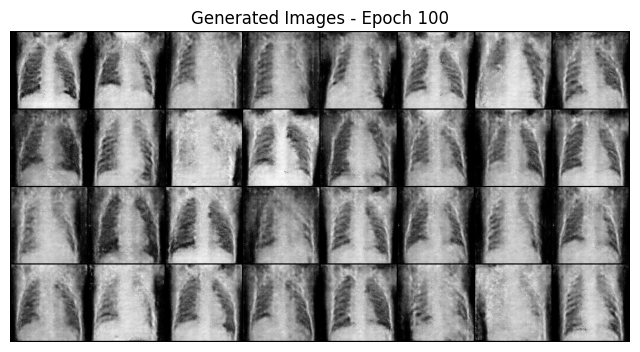

🕒 Epoch 100/5000 completed in 104.32 sec.
[104/5000][48/163] Loss_D: 2.3988 Loss_G: 0.8914 D(x): 0.4507 D(G(z)): 0.5250 / 0.5843
[110/5000][70/163] Loss_D: 2.2753 Loss_G: 0.8957 D(x): 0.4648 D(G(z)): 0.4913 / 0.5903
[116/5000][92/163] Loss_D: 2.1324 Loss_G: 0.9795 D(x): 0.4585 D(G(z)): 0.4256 / 0.5434
[122/5000][114/163] Loss_D: 1.9762 Loss_G: 0.9490 D(x): 0.5272 D(G(z)): 0.4603 / 0.5527
🕒 Epoch 125/5000 completed in 79.98 sec.
[128/5000][136/163] Loss_D: 2.2198 Loss_G: 1.0624 D(x): 0.5125 D(G(z)): 0.5488 / 0.4938
[134/5000][158/163] Loss_D: 2.2165 Loss_G: 1.1369 D(x): 0.5044 D(G(z)): 0.5365 / 0.4602
[141/5000][17/163] Loss_D: 2.3496 Loss_G: 0.9759 D(x): 0.4197 D(G(z)): 0.4921 / 0.5519
[147/5000][39/163] Loss_D: 2.1520 Loss_G: 1.0776 D(x): 0.4682 D(G(z)): 0.4761 / 0.4788


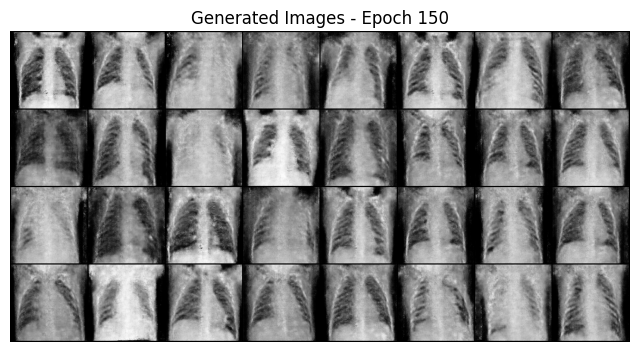

🕒 Epoch 150/5000 completed in 80.30 sec.
[153/5000][61/163] Loss_D: 2.2503 Loss_G: 0.9291 D(x): 0.4862 D(G(z)): 0.5335 / 0.5628
[159/5000][83/163] Loss_D: 2.2102 Loss_G: 1.0303 D(x): 0.5334 D(G(z)): 0.5523 / 0.5097
[165/5000][105/163] Loss_D: 2.0401 Loss_G: 0.9530 D(x): 0.5112 D(G(z)): 0.4747 / 0.5518
[171/5000][127/163] Loss_D: 1.9964 Loss_G: 1.0252 D(x): 0.5365 D(G(z)): 0.4960 / 0.5117
🕒 Epoch 175/5000 completed in 75.80 sec.
[177/5000][149/163] Loss_D: 2.2356 Loss_G: 0.9328 D(x): 0.4846 D(G(z)): 0.5244 / 0.5542
[184/5000][8/163] Loss_D: 2.0592 Loss_G: 0.9465 D(x): 0.4738 D(G(z)): 0.4086 / 0.5444
[190/5000][30/163] Loss_D: 2.0746 Loss_G: 0.9825 D(x): 0.5530 D(G(z)): 0.5266 / 0.5350
[196/5000][52/163] Loss_D: 2.1078 Loss_G: 0.9755 D(x): 0.4859 D(G(z)): 0.4690 / 0.5385


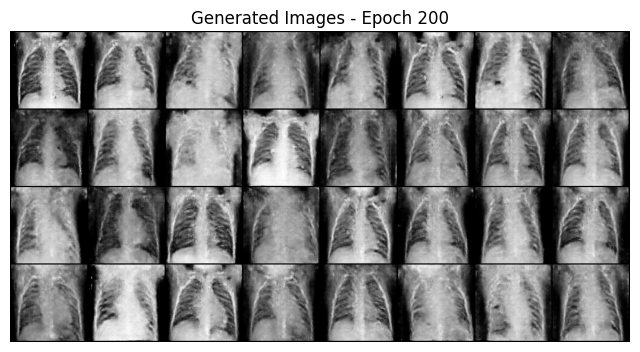

🕒 Epoch 200/5000 completed in 80.76 sec.
[202/5000][74/163] Loss_D: 1.9786 Loss_G: 1.0111 D(x): 0.4848 D(G(z)): 0.4252 / 0.5307
[208/5000][96/163] Loss_D: 2.0905 Loss_G: 0.9475 D(x): 0.5366 D(G(z)): 0.5134 / 0.5521
[214/5000][118/163] Loss_D: 2.2221 Loss_G: 0.9951 D(x): 0.5140 D(G(z)): 0.5207 / 0.5228
[220/5000][140/163] Loss_D: 2.1265 Loss_G: 1.0525 D(x): 0.4783 D(G(z)): 0.4879 / 0.4918
🕒 Epoch 225/5000 completed in 76.07 sec.
[226/5000][162/163] Loss_D: 2.1245 Loss_G: 1.0033 D(x): 0.4955 D(G(z)): 0.5055 / 0.5282
[233/5000][21/163] Loss_D: 2.1397 Loss_G: 1.0014 D(x): 0.5085 D(G(z)): 0.5246 / 0.5167
[239/5000][43/163] Loss_D: 2.2024 Loss_G: 1.0452 D(x): 0.4868 D(G(z)): 0.5120 / 0.4972
[245/5000][65/163] Loss_D: 2.1543 Loss_G: 1.0380 D(x): 0.5253 D(G(z)): 0.5443 / 0.5064


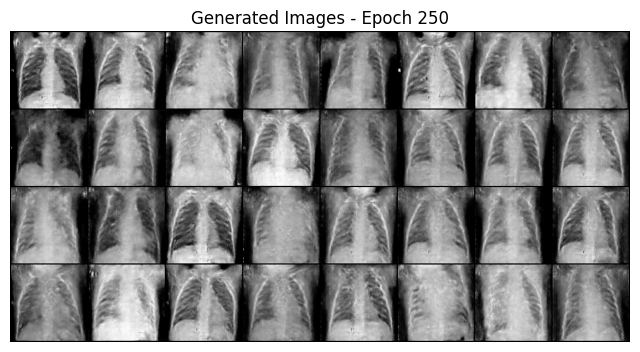

🕒 Epoch 250/5000 completed in 77.13 sec.
[251/5000][87/163] Loss_D: 2.1151 Loss_G: 1.0694 D(x): 0.4752 D(G(z)): 0.4742 / 0.4903
[257/5000][109/163] Loss_D: 2.0535 Loss_G: 1.1671 D(x): 0.5073 D(G(z)): 0.4762 / 0.4376
[263/5000][131/163] Loss_D: 1.9704 Loss_G: 0.9298 D(x): 0.5050 D(G(z)): 0.4436 / 0.5562
[269/5000][153/163] Loss_D: 2.3066 Loss_G: 0.9382 D(x): 0.4115 D(G(z)): 0.4643 / 0.5576
🕒 Epoch 275/5000 completed in 75.85 sec.
[276/5000][12/163] Loss_D: 2.0539 Loss_G: 1.0453 D(x): 0.5175 D(G(z)): 0.5119 / 0.5009
[282/5000][34/163] Loss_D: 2.1506 Loss_G: 1.0230 D(x): 0.5040 D(G(z)): 0.5387 / 0.5078
[288/5000][56/163] Loss_D: 2.1225 Loss_G: 0.9457 D(x): 0.5571 D(G(z)): 0.5613 / 0.5502
[294/5000][78/163] Loss_D: 2.0770 Loss_G: 0.9859 D(x): 0.5089 D(G(z)): 0.5159 / 0.5287


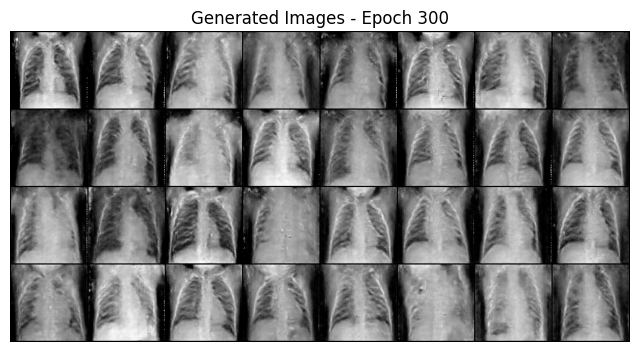

🕒 Epoch 300/5000 completed in 76.70 sec.
[300/5000][100/163] Loss_D: 2.1951 Loss_G: 1.0006 D(x): 0.5019 D(G(z)): 0.5540 / 0.5218
[306/5000][122/163] Loss_D: 2.1839 Loss_G: 1.0659 D(x): 0.4714 D(G(z)): 0.5138 / 0.4966
[312/5000][144/163] Loss_D: 2.0182 Loss_G: 1.0553 D(x): 0.4760 D(G(z)): 0.4442 / 0.4934
[319/5000][3/163] Loss_D: 2.0770 Loss_G: 0.9689 D(x): 0.5328 D(G(z)): 0.5372 / 0.5343
🕒 Epoch 325/5000 completed in 108.88 sec.
[325/5000][25/163] Loss_D: 2.1892 Loss_G: 0.9491 D(x): 0.4888 D(G(z)): 0.5282 / 0.5445
[331/5000][47/163] Loss_D: 2.1282 Loss_G: 1.1300 D(x): 0.4964 D(G(z)): 0.4989 / 0.4576
[337/5000][69/163] Loss_D: 1.9851 Loss_G: 1.0637 D(x): 0.5232 D(G(z)): 0.4736 / 0.4885
[343/5000][91/163] Loss_D: 2.1877 Loss_G: 0.9906 D(x): 0.4903 D(G(z)): 0.5124 / 0.5193
[349/5000][113/163] Loss_D: 2.1208 Loss_G: 1.0974 D(x): 0.4919 D(G(z)): 0.5084 / 0.4759


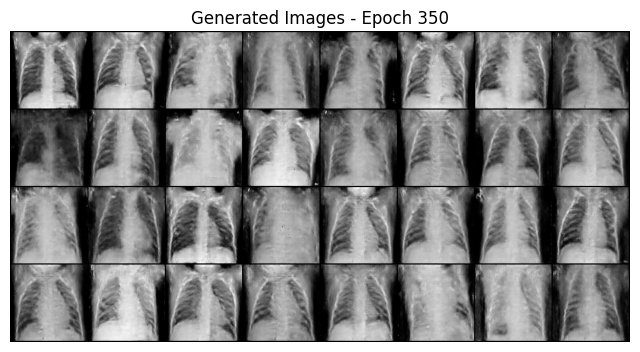

🕒 Epoch 350/5000 completed in 75.92 sec.
[355/5000][135/163] Loss_D: 2.0908 Loss_G: 0.9911 D(x): 0.5096 D(G(z)): 0.5214 / 0.5218
[361/5000][157/163] Loss_D: 2.2066 Loss_G: 0.9205 D(x): 0.4447 D(G(z)): 0.4938 / 0.5573
[368/5000][16/163] Loss_D: 2.0825 Loss_G: 0.9808 D(x): 0.5272 D(G(z)): 0.5101 / 0.5287
[374/5000][38/163] Loss_D: 2.0514 Loss_G: 0.9484 D(x): 0.4902 D(G(z)): 0.4612 / 0.5380
🕒 Epoch 375/5000 completed in 75.70 sec.
[380/5000][60/163] Loss_D: 2.1119 Loss_G: 0.9367 D(x): 0.4801 D(G(z)): 0.5074 / 0.5439
[386/5000][82/163] Loss_D: 2.0438 Loss_G: 1.0116 D(x): 0.4636 D(G(z)): 0.4544 / 0.5065
[392/5000][104/163] Loss_D: 2.0738 Loss_G: 0.9920 D(x): 0.5003 D(G(z)): 0.4879 / 0.5259
[398/5000][126/163] Loss_D: 2.0923 Loss_G: 0.9312 D(x): 0.4883 D(G(z)): 0.5005 / 0.5463


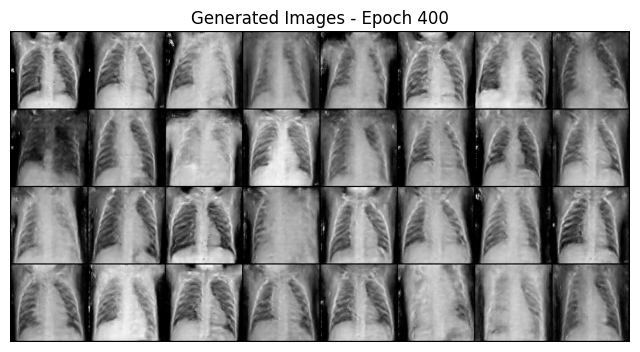

🕒 Epoch 400/5000 completed in 91.99 sec.
[404/5000][148/163] Loss_D: 2.0878 Loss_G: 0.9326 D(x): 0.5071 D(G(z)): 0.5204 / 0.5456
[411/5000][7/163] Loss_D: 2.0535 Loss_G: 0.9271 D(x): 0.5085 D(G(z)): 0.5080 / 0.5528
[417/5000][29/163] Loss_D: 2.0301 Loss_G: 0.9487 D(x): 0.5223 D(G(z)): 0.4942 / 0.5405
[423/5000][51/163] Loss_D: 2.1402 Loss_G: 0.9916 D(x): 0.4914 D(G(z)): 0.5258 / 0.5172
🕒 Epoch 425/5000 completed in 77.38 sec.
[429/5000][73/163] Loss_D: 1.9919 Loss_G: 0.9481 D(x): 0.5160 D(G(z)): 0.4847 / 0.5447
[435/5000][95/163] Loss_D: 1.9667 Loss_G: 0.9880 D(x): 0.4941 D(G(z)): 0.4538 / 0.5192
[441/5000][117/163] Loss_D: 2.2446 Loss_G: 0.9757 D(x): 0.4697 D(G(z)): 0.5281 / 0.5238
[447/5000][139/163] Loss_D: 2.0829 Loss_G: 0.8695 D(x): 0.5056 D(G(z)): 0.5050 / 0.5813


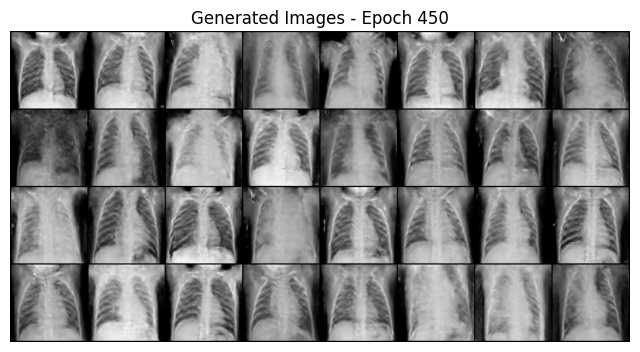

🕒 Epoch 450/5000 completed in 80.10 sec.
[453/5000][161/163] Loss_D: 2.0479 Loss_G: 0.9088 D(x): 0.5008 D(G(z)): 0.4968 / 0.5600
[460/5000][20/163] Loss_D: 2.0869 Loss_G: 0.9676 D(x): 0.4742 D(G(z)): 0.4707 / 0.5396
[466/5000][42/163] Loss_D: 2.0479 Loss_G: 0.9466 D(x): 0.5170 D(G(z)): 0.5160 / 0.5395
[472/5000][64/163] Loss_D: 2.1130 Loss_G: 1.0156 D(x): 0.4760 D(G(z)): 0.4816 / 0.5063
🕒 Epoch 475/5000 completed in 79.70 sec.
[478/5000][86/163] Loss_D: 2.0359 Loss_G: 0.9636 D(x): 0.5164 D(G(z)): 0.4965 / 0.5313
[484/5000][108/163] Loss_D: 2.0292 Loss_G: 0.9580 D(x): 0.5123 D(G(z)): 0.4938 / 0.5335
[490/5000][130/163] Loss_D: 2.1473 Loss_G: 0.9479 D(x): 0.4574 D(G(z)): 0.4863 / 0.5374
[496/5000][152/163] Loss_D: 2.0921 Loss_G: 0.9486 D(x): 0.5180 D(G(z)): 0.5045 / 0.5463


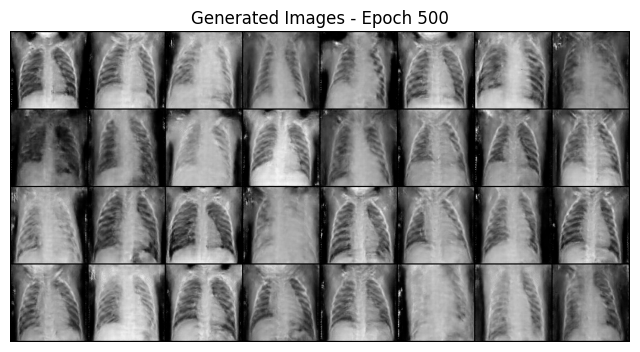

🕒 Epoch 500/5000 completed in 91.80 sec.
✅ Epoch 501: Loss improved to 2.9680, resetting patience counter.
⚠️ Epoch 502: No significant improvement. Patience: 1/50
⚠️ Epoch 503: No significant improvement. Patience: 2/50
[503/5000][11/163] Loss_D: 2.0049 Loss_G: 0.9901 D(x): 0.5392 D(G(z)): 0.5159 / 0.5210
✅ Epoch 504: Loss improved to 2.9292, resetting patience counter.
✅ Epoch 505: Loss improved to 2.9209, resetting patience counter.
✅ Epoch 506: Loss improved to 2.8571, resetting patience counter.
⚠️ Epoch 507: No significant improvement. Patience: 1/50
⚠️ Epoch 508: No significant improvement. Patience: 2/50
⚠️ Epoch 509: No significant improvement. Patience: 3/50
[509/5000][33/163] Loss_D: 2.1656 Loss_G: 0.9137 D(x): 0.4657 D(G(z)): 0.5175 / 0.5533
⚠️ Epoch 510: No significant improvement. Patience: 4/50
⚠️ Epoch 511: No significant improvement. Patience: 5/50
⚠️ Epoch 512: No significant improvement. Patience: 6/50
⚠️ Epoch 513: No significant improvement. Patience: 7/50
⚠️ Epoch

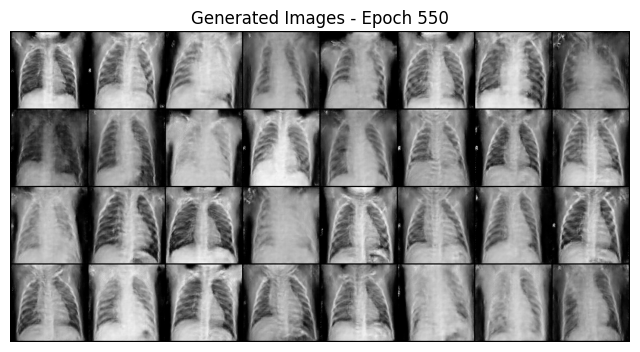

⚠️ Epoch 550: No significant improvement. Patience: 4/50
🕒 Epoch 550/5000 completed in 92.51 sec.
⚠️ Epoch 551: No significant improvement. Patience: 5/50
⚠️ Epoch 552: No significant improvement. Patience: 6/50
[552/5000][24/163] Loss_D: 2.0661 Loss_G: 0.9167 D(x): 0.5294 D(G(z)): 0.5372 / 0.5525
⚠️ Epoch 553: No significant improvement. Patience: 7/50
⚠️ Epoch 554: No significant improvement. Patience: 8/50
⚠️ Epoch 555: No significant improvement. Patience: 9/50
⚠️ Epoch 556: No significant improvement. Patience: 10/50
⚠️ Epoch 557: No significant improvement. Patience: 11/50
⚠️ Epoch 558: No significant improvement. Patience: 12/50
[558/5000][46/163] Loss_D: 2.1115 Loss_G: 0.9021 D(x): 0.4612 D(G(z)): 0.4831 / 0.5632
⚠️ Epoch 559: No significant improvement. Patience: 13/50
⚠️ Epoch 560: No significant improvement. Patience: 14/50
⚠️ Epoch 561: No significant improvement. Patience: 15/50
⚠️ Epoch 562: No significant improvement. Patience: 16/50
⚠️ Epoch 563: No significant improvem

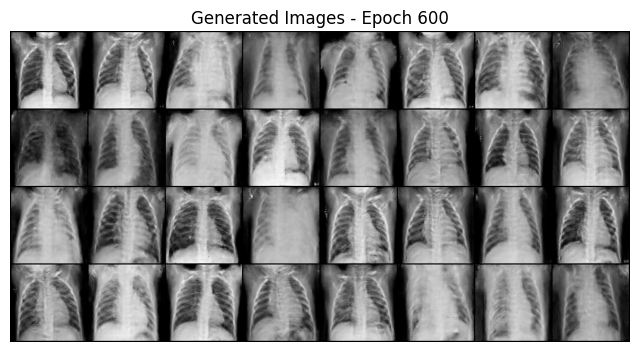

⚠️ Epoch 600: No significant improvement. Patience: 7/50
🕒 Epoch 600/5000 completed in 92.00 sec.
⚠️ Epoch 601: No significant improvement. Patience: 8/50
[601/5000][37/163] Loss_D: 2.0275 Loss_G: 0.9313 D(x): 0.5070 D(G(z)): 0.4973 / 0.5474
⚠️ Epoch 602: No significant improvement. Patience: 9/50
⚠️ Epoch 603: No significant improvement. Patience: 10/50
⚠️ Epoch 604: No significant improvement. Patience: 11/50
⚠️ Epoch 605: No significant improvement. Patience: 12/50
⚠️ Epoch 606: No significant improvement. Patience: 13/50
⚠️ Epoch 607: No significant improvement. Patience: 14/50
[607/5000][59/163] Loss_D: 2.1729 Loss_G: 0.8231 D(x): 0.5037 D(G(z)): 0.5492 / 0.6083
⚠️ Epoch 608: No significant improvement. Patience: 15/50
⚠️ Epoch 609: No significant improvement. Patience: 16/50
⚠️ Epoch 610: No significant improvement. Patience: 17/50
⚠️ Epoch 611: No significant improvement. Patience: 18/50
⚠️ Epoch 612: No significant improvement. Patience: 19/50
⚠️ Epoch 613: No significant impro

In [ ]:
# ✅ Training Loop

generator_model_name = "ACGAN_128_Generator.pth"
discriminator_model_name = "ACGAN_128_Discriminator.pth"

# Lists to track progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("🚀 Starting Training Loop...")

for epoch in range(num_epochs):
    start_time = time.time()  # Track time for each epoch

    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update Discriminator
        ############################
        netD.zero_grad()
        real_cpu = data[0].to(device)  # ✅ Move image tensor to GPU
        real_labels = data[1].to(device, dtype=torch.long)  # ✅ Move label tensor to GPU
        b_size = real_cpu.size(0)

        # ✅ Add Gaussian Noise to weaken D
        real_cpu += torch.randn_like(real_cpu) * discriminator_noise_std

        output_real, class_real = netD(real_cpu)  # ✅ Get both real/fake & class predictions

        label_real = torch.full((b_size,), 1.0, dtype=torch.float, device=device)  # ✅ Real labels = 1
        errD_real = criterion_GAN(output_real, label_real)  # ✅ Real/Fake loss
        errD_class = criterion_class(class_real, real_labels)  # ✅ Class prediction loss (Fixed)
        errD_total = errD_real + lambda_class * errD_class  # ✅ Weighted sum

        errD_total.backward()
        D_x = output_real.mean().item()

        # ✅ Generate Fake Images
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_labels = torch.randint(0, num_classes, (b_size,), device=device, dtype=torch.long)
        fake = netG(noise, fake_labels)

        # ✅ Add noise to fake images
        fake += torch.randn_like(fake) * discriminator_noise_std

        output_fake, class_fake = netD(fake.detach())  # ✅ Get both outputs

        label_fake = torch.full((b_size,), 0.0, dtype=torch.float, device=device)  # ✅ Fake labels = 0
        errD_fake = criterion_GAN(output_fake, label_fake)  # ✅ Fake image loss
        errD_class_fake = criterion_class(class_fake, fake_labels)  # ✅ Fake class prediction loss (Fixed)
        errD_total_fake = errD_fake + lambda_class * errD_class_fake

        errD_total_fake.backward()
        D_G_z1 = output_fake.mean().item()

        errD = errD_total + errD_total_fake
        optimizerD.step()

        ############################
        # (2) Update Generator
        ############################
        for _ in range(gen_update_steps):
            netG.zero_grad()
            fake = netG(noise, fake_labels)
            output, class_output = netD(fake)

            label_g = torch.full((b_size,), 1.0, dtype=torch.float, device=device)  # ✅ Trick D to think fake is real
            errG = criterion_GAN(output, label_g)  # ✅ Generator Adversarial Loss
            errG_class = criterion_class(class_output, fake_labels)  # ✅ Generator Class Consistency Loss (Fixed)
            errG_total = errG + lambda_class * errG_class  # ✅ Weighted sum

            errG_total.backward()
            optimizerG.step()

        D_G_z2 = output.mean().item()

        # ✅ Print every 1000 iterations
        if iters % 1000 == 0:
            print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] "
                  f"Loss_D: {errD.item():.4f} Loss_G: {errG_total.item():.4f} "
                  f"D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}")

        G_losses.append(errG_total.item())
        D_losses.append(errD.item())

        iters += 1

    # 📸 **Display generated images every 50 epochs**
    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            fake_images = netG(fixed_noise, fixed_labels)
        display_generated_images(fake_images, epoch)

        # Save images to list for further evaluation
        img_list.append(fake_images)

    # 📉 Early stopping
    total_loss = errG_total.item() + errD.item()
    if epoch >= min_epochs:
        if min_loss - total_loss > g_d_loss_delta:
            min_loss = total_loss
            epochs_no_improve = 0
            print(f"✅ Epoch {epoch+1}: Loss improved to {min_loss:.4f}, resetting patience counter.")
        else:
            epochs_no_improve += 1
            print(f"⚠️ Epoch {epoch+1}: No significant improvement. Patience: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}. Saving final model...")
            torch.save(netG.state_dict(), generator_model_name)
            torch.save(netD.state_dict(), discriminator_model_name)
            break

    # 📉 Update learning rate scheduler
    schedulerD.step()
    schedulerG.step()

    # ✅ Print time taken for the epoch
    print_processing_status(epoch, num_epochs, start_time)

# 💾 Final model save
print("✅ Training complete. Saving final model...")
torch.save(netG.state_dict(), generator_model_name)
torch.save(netD.state_dict(), discriminator_model_name)


# Model Visualization

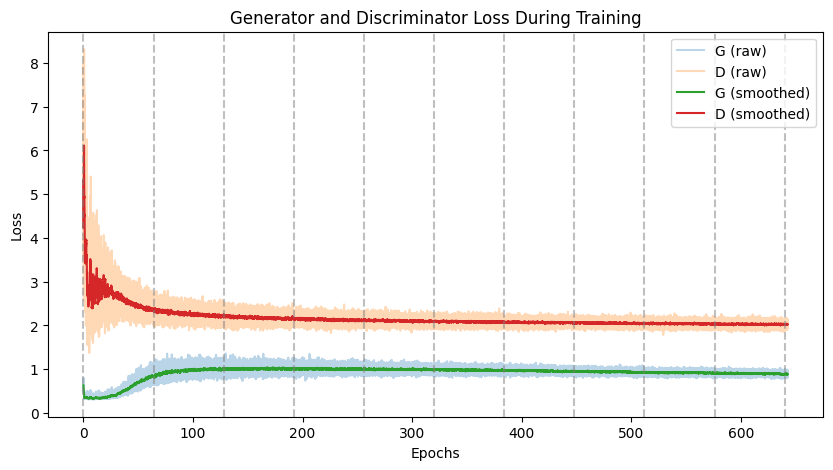

In [ ]:
def moving_average(values, window=50):
    return np.convolve(values, np.ones(window)/window, mode='valid')

# ✅ Fix: Use actual number of epochs (not predefined num_epochs)
actual_epochs = epoch + 1  # ✅ Last epoch that actually ran

# ✅ Fix: Rescale x-axis dynamically
epochs = np.linspace(0, actual_epochs, len(G_losses))

plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")

# Original Loss
plt.plot(epochs, G_losses, alpha=0.3, label="G (raw)")
plt.plot(epochs, D_losses, alpha=0.3, label="D (raw)")

# Optional: Track Classification Loss for Discriminator (if logged separately)
if 'D_class_losses' in globals():
    plt.plot(epochs, D_class_losses, alpha=0.3, label="D (class loss)", linestyle="dotted")

# Smoothed Loss
plt.plot(epochs[:len(moving_average(G_losses))], moving_average(G_losses), label="G (smoothed)")
plt.plot(epochs[:len(moving_average(D_losses))], moving_average(D_losses), label="D (smoothed)")

# Optional: Smooth Class Loss (if available)
if 'D_class_losses' in globals():
    plt.plot(epochs[:len(moving_average(D_class_losses))], moving_average(D_class_losses), label="D (class loss smoothed)", linestyle="dotted")

plt.xlabel("Epochs")  # ✅ Now correctly labeled
plt.ylabel("Loss")
plt.legend()

# ✅ Fix: Scale vertical lines based on actual epochs
for i in range(0, actual_epochs, max(actual_epochs // 10, 1)):
    plt.axvline(x=i, color='gray', linestyle='--', alpha=0.5)

plt.show()


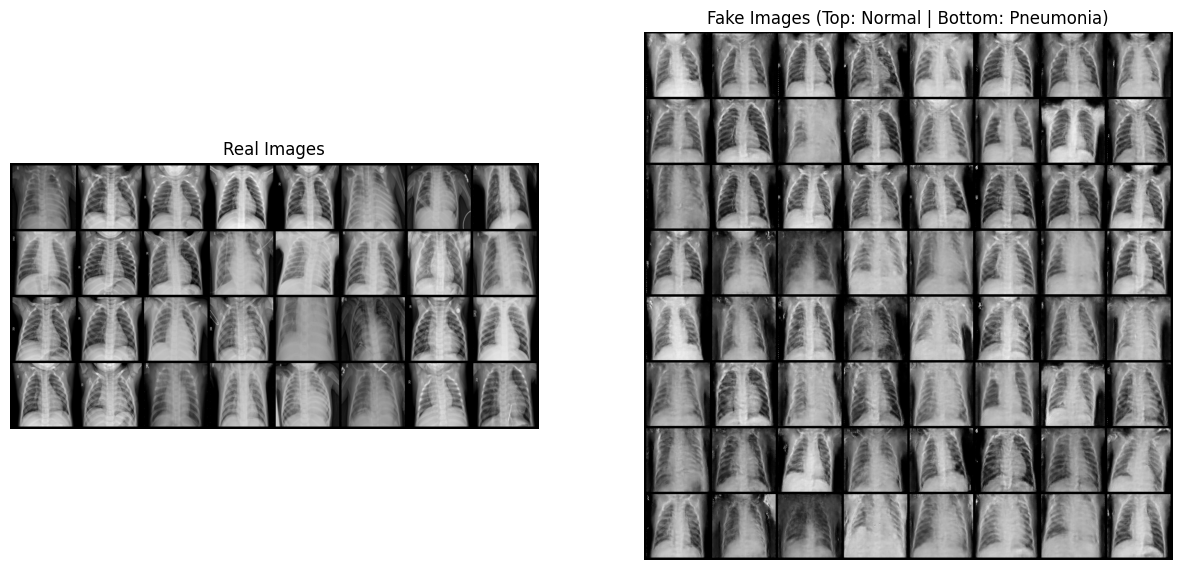

In [ ]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(), (1, 2, 0)))

# ✅ Generate fake images conditioned on both classes
with torch.no_grad():
    class_0_labels = torch.zeros(32, dtype=torch.long, device=device)  # Normal X-ray class
    class_1_labels = torch.ones(32, dtype=torch.long, device=device)  # Pneumonia X-ray class

    noise = torch.randn(32, nz, 1, 1, device=device)

    fake_class_0 = netG(noise, class_0_labels)  # Generate class 0 (Normal)
    fake_class_1 = netG(noise, class_1_labels)  # Generate class 1 (Pneumonia)

# ✅ Create a visualization grid for class-conditioned fake images
fake_grid = torch.cat([fake_class_0, fake_class_1], dim=0)
fake_images = np.transpose(vutils.make_grid(fake_grid, padding=5, normalize=True).cpu(), (1, 2, 0))

# Plot the fake images from the last epoch
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images (Top: Normal | Bottom: Pneumonia)")
plt.imshow(fake_images)
plt.show()


# Generate Synethetic Dataset

In [15]:
# Load the trained models
import torch
import os

# Define device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model architectures
netG = Generator(ngpu, num_classes).to(device)
netD = Discriminator(ngpu, num_classes).to(device)

# Load the trained weights
netG.load_state_dict(torch.load("ACGAN_128_Generator.pth", map_location=device))
netD.load_state_dict(torch.load("ACGAN_128_Discriminator.pth", map_location=device))

# Set models to evaluation mode
netG.eval()
netD.eval()

print("✅ Successfully loaded trained ACGAN models!")


✅ Successfully loaded trained ACGAN models!


In [18]:
import os
import torch
import torchvision.transforms as transforms

# Directories to save synthetic datasets
save_dir_normal = "ACGAN_128_synthetic_normal"
save_dir_pneumonia = "ACGAN_128_synthetic_pneumonia"

os.makedirs(save_dir_normal, exist_ok=True)
os.makedirs(save_dir_pneumonia, exist_ok=True)

# Number of images to generate per class
num_images_per_class = 1000  # Adjust based on need

# ✅ Function to denormalize images (Convert from [-1,1] to [0,1] for saving)
def denormalize(tensor):
    return (tensor + 1) / 2  # Scale from [-1,1] to [0,1]

for i in range(num_images_per_class):
    noise = torch.randn(1, nz, 1, 1, device=device)  # Generate random noise

    with torch.no_grad():
        # ✅ Generate Normal X-ray (class 0)
        fake_normal = netG(noise, torch.tensor([0], dtype=torch.long, device=device)).detach().cpu()
        # ✅ Generate Pneumonia X-ray (class 1)
        fake_pneumonia = netG(noise, torch.tensor([1], dtype=torch.long, device=device)).detach().cpu()

    # ✅ Apply denormalization before converting to PIL
    normal_pil = transforms.ToPILImage()(denormalize(fake_normal.squeeze(0)))
    pneumonia_pil = transforms.ToPILImage()(denormalize(fake_pneumonia.squeeze(0)))

    normal_pil.save(f"{save_dir_normal}/normal_{i}.png")
    pneumonia_pil.save(f"{save_dir_pneumonia}/pneumonia_{i}.png")

print(f"✅ Generated {num_images_per_class} synthetic normal images in {save_dir_normal}")
print(f"✅ Generated {num_images_per_class} synthetic pneumonia images in {save_dir_pneumonia}")


✅ Generated 1000 synthetic normal images in ACGAN_128_synthetic_normal
✅ Generated 1000 synthetic pneumonia images in ACGAN_128_synthetic_pneumonia
